# Rekursionen

Eine Funktion kann sich selbst aufrufen. Dies nennt man Rekursion. Rekursion kann verwendet werden, um Probleme zu lösen, die sich in kleinere Teilprobleme zerlegen lassen.

Diese Konzept ist sehr natürlich in der Mathematik, z.B. bei der Definition von Faktoriellen:

$$
n! = \begin{cases}
1 & \text{wenn } n = 0 \\
n \times (n-1)! & \text{wenn } n > 0
\end{cases}
$$

Hier wird ein Problem (Berechnung von $n!$) auf ein einfacheres Problem (Berechnung von $(n-1)!$) zurückgeführt.

__Wichtig__:
- Jede rekursive Funktion muss eine Abbruchbedingung haben, um unendliche Rekursion zu vermeiden.
- Rekursive Funktionen können oft durch Schleifen (später) ersetzt werden, was in manchen Fällen effizienter ist.
- Rekursion ist oft eleganter und einfacher zu verstehen, Schleifen sind oft effizienter.



### Beispiel: Faktorielle 

In [4]:
def factorial(n):
    if n < 0:
        return -1 # Factorial is not defined for negative input, return -1 as error code
    elif n == 0:
        return 1 # stopping condition 0! = 1
    else:
        return n * factorial(n - 1)  # recursion step n! = n * (n-1)!

print("3! =",factorial(3))

3! = 6


- Im obigen Beispiel kann man die `else` Klauseln auch weglassen, da mit `return` die Funktion sofort verlassen wird

In [2]:
def factorial(n):
    if n < 0:
        return -1 # Factorial is not defined for negative input, return -1 as error code
    if n == 0:
        return 1  # stopping condition 0! = 1
    return n * factorial(n - 1)  # recursion step n! = n * (n-1)!

print("5! =",factorial(5))

5! = 120


### Beispiel: Visualisierung der Rekursion
Um die Reihenfolge der Funktionsaufrufe zu visualisieren, verwenden wir eine sehr einfache Version der Funktion.

```python
def factorial(n):
    if n==0:
        return 1
    return n * factorial(n-1)
```


Das folgende Bild zeigt den Rekursionsbaum für den Aufruf `factorial(3)`:
- Die schwarzen Pfeile illustrieren die Selbstaufrufe der Funktion
- Die orangefarbenen Pfeile zeigen die Rückgabe der Ergebnisse
- Funktionsblöcke die übereinander liegen visualisieren den selben Aufruf, vor (oben) und nach (unten) der Rückgabe

<img src="illustrations/recursion.png" style="width: 800px;"/>

### Beispiel: Fibonacci-Zahlen
Die Fibonacci-Zahlen sind eine Folge von Zahlen, bei der jede Zahl die Summe der beiden vorhergehenden ist. Die Folge beginnt mit 0 und 1.
Mathematisch ist die Fibonacci-Folge definiert als: $f_0 =0$, $f_1 =1$ und

$$
f_n = f_{n-1} + f_{n-2} \quad\text{ für } n \geq 2
$$

In [3]:
def fibonacci(n):
    if n < 0:
        return -1 # Fibonacci is not defined for negative input, return -1 as error code
    elif n == 0:
        return 0 # stopping condition f_0 = 0
    elif n == 1:
        return 1 # stopping condition f_1 = 1
    else:
        return fibonacci(n - 1) + fibonacci(n - 2)  # recursion step f_n = f_(n-1) + f_(n-2)
    
print("f_10 =",fibonacci(10))

f_10 = 55


## Rekursionstiefe
Als Rekursionstiefe bezeichnet man die maximale Anzahl von gleichzeitig laufenden Aufrufen der selben Funktion.
Ein Aufruf ist "laufend", wenn er noch nicht beendet ist (also noch kein Ergebnis zurückgegeben wurde).
- Die Rekursionstiefe hängt immer vom Eingabewert ab, z.B.:
    - `factorial(3)` hat eine Rekursionstiefe von 4 (Aufrufe: `factorial(3)`, `factorial(2)`, `factorial(1)`, `factorial(0)`)
    - `fibonacci(5)` hat eine Rekursionstiefe von 9 (Aufrufe: `fibonacci(5)`, `fibonacci(4)`, 2x`fibonacci(3)`, 2x`fibonacci(2)`, 2x`fibonacci(1)`, `fibonacci(0)`)
    - Die Rekursionstiefe kann exponentiell mit dem Eingabewert wachsen (wie bei Fibonacci)
- __Hohe Rekursionstiefe führt oft zu Performance-Problemen__
- Die Rekursionstiefe ist von Python selbst begrenzt und kann mit `sys.getrecursionlimit()` abgefragt und mit `sys.setrecursionlimit(n)` geändert werden.
    - Wird die maximale Rekursionstiefe überschritten, wird eine Fehlermeldung ausgegeben und das Programm abgebrochen.
    - Achtung: Eine zu hohe Rekursionstiefe kann dazu führen, dass der Python-Interpreter abstürzt.


In [4]:
import sys
print("Recursion depth:", sys.getrecursionlimit())

Recursion depth: 3000


Mit einer globalen Zählvariable `func_calls` können wir die Anzahl der Funktionsaufrufe messen:

In [12]:
func_calls = 0
def fibonacci(n):
    global func_calls
    func_calls += 1
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        return fibonacci(n-1) + fibonacci(n-2)

print("f_30 =",fibonacci(30))
print("Function calls:", func_calls)

f_30 = 832040
Function calls: 2692537


Durch eine einfache Optimierung können wir die Anzahl der Funktionsaufrufe drastisch reduzieren:
- Statt `fibonacci(n-1)` und `fibonacci(n-2)` separat zu berechnen, können wir das Ergebnis von `fibonacci(n-2)` wiederverwenden, um `fibonacci(n-1)` zu erhalten.
- `fibonacci(n)` gibt jetzt ein Tupel zurück: $(f_n, f_{n-1})$
- Dadurch wird die Anzahl der Funktionsaufrufe auf $n$ reduziert.

In [9]:
func_calls = 0
def fibonacci(n):
    global func_calls
    func_calls += 1
    if n == 0:
        return 0, 0
    elif n == 1:
        return 1, 0
    else:
        fn_1, fn_2 = fibonacci(n-1)
        return fn_1 + fn_2, fn_1

print("f_30 =",fibonacci(30)[0])
print("Function calls:", func_calls)

f_30 = 832040
Function calls: 30


### Beispiel: Nullstellensuche mit dem Bisektionsverfahren
- Das Bisektionsverfahren ist ein numerisches Verfahren zur Bestimmung von Nullstellen einer Funktion. Es basiert auf dem Zwischenwertsatz, der besagt, dass eine stetige Funktion, die an zwei Punkten unterschiedliche Vorzeichen hat, mindestens eine Nullstelle zwischen diesen Punkten besitzt.

- __Gegeben__: Stetige Funktion $f: [a, b] \rightarrow \mathbb{R}$ mit $f(a)  f(b) \leq 0$ (d.h. $f(a)$ und $f(b)$ haben unterschiedliche Vorzeichen) und eine vorgegebene Genauigkeit $\tau > 0$.

- __Tatsache__: Nach dem Zwischenwertsatz existiert mindestens eine Nullstelle $x^*\in [a, b]$ von $f$, also $f(x^*) = 0$.
- __Gesucht__: Approximation der Nullstelle: Ein Wert $x_0 \in [a,b]$ mit der Eigenschaft $|x_0-x^*| < \tau$.

- __Bisektionsverfahren__:
  1. Solange die Intervalbreite $|b-a|>2\tau$ ist, wiederhole die folgenden Schritte:
     1. Berechne den Mittelpunkt $m = \frac{a + b}{2}$.
     3. Wenn $f(m) f(a) < 0$, dann liegt die Nullstelle im Intervall $[a, m]$. Setze $b = m$.
     4. Andernfalls liegt die Nullstelle im Intervall $[m, b]$. Setze $a = m$.

- Das Verfahren basiert nur auf dem Zwischenwertsatz
- Das Verfahren terminiert immer, da die Intervallbreite in jedem Schritt halbiert wird.

### Illustration des Bisektionsverfahrens

<img src="illustrations/bisect4.gif" alt="Bisektionsverfahren Illustration" width="800"/>


In [5]:
def f(x):
    return x**2 + 1/(2+x)-2

def bisection(f, a, b, tol):
    m = 0.5 * (a + b)
    if b-a < 2*tol:
        return m
    if f(a)*f(m) <= 0:
        return bisection(f, a, m, tol)
    else:
        return bisection(f, m, b, tol)

print("Root of f is approximately at x =", bisection(f, 0, 3, 0.001))

Root of f is approximately at x = 1.302978515625


### Beispiel: Finde den kürzesten Weg

Mit Hilfe von geschachtelten Listen können wir ein Labyrinth in einem quadratischen Gebiet darstellen. 
- Dabei steht `0` für einen freien Weg und `1` für eine Wand.
- Wir legen Startpunkt und Zielpunkt fest und suchen den kürzesten Weg dazwischen.

In [10]:
n=10
maze = [[0]*n for _ in range(n)]
walls = [(2,8),(0,9),(1,7),(2,2),(2,3),(2,4),(2,5),
         (2,6),(2,7),(3,2),(4,2),(7,2),(6,2),(8,2),
         (4,7),(5,1),(5,2),(5,3),(5,4),(5,5),(5,6),
         (5,7),(6,2),(6,6),(7,6),(3,5),(7,4),(8,4),
         (9,4),(8,6),(8,7),(8,8)]
for (x,y) in walls:
    maze[x][y]=1

start = (9,1)
goal = (3,4)

Um das Labyrinth zu visualisieren, verwenden wir die folgende Funktion. Die Erklärung zu dieser Visualisierung folgt im Kapitel 'Visualisierung mit Matplotlib'.
Sie können die Implementierung vorerst ignorieren.

In [11]:
def print_maze(maze, path=None, start=None, goal=None, dist = None):
    import matplotlib.pyplot as plt
    plt.scatter([x for (x,y) in walls],[y for (x,y) in walls], color='lightblue', marker='s', s=600)
    plt.plot([-0.5,n-0.5,n-0.5,-0.5,-0.5],[-0.5,-0.5,n-0.5,n-0.5,-0.5], color='lightblue', linewidth=3)
    if path:
        plt.plot([x for (x,y) in path], [y for (x,y) in path], color='orange', linewidth=3)
    if goal:
        plt.scatter(goal[0],goal[1], color='red', marker='*', s=200)
    if start:
        plt.scatter(start[0], start[1], color='orange', marker='o', s=200)
    if dist:
        for i in range(n):
            for j in range(n):
                if maze[i][j]==0 and dist[i][j]<float('inf'):
                    plt.text(i,j,str(dist[i][j]), color='black', fontsize=12, ha='center', va='center')
    plt.xlim(-1,n)
    plt.ylim(-1,n)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

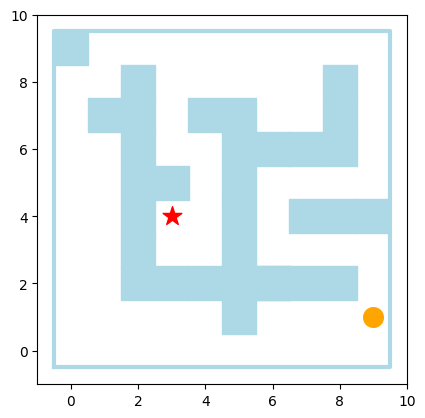

In [12]:
print_maze(maze,start=start, goal=goal)

Um den kürzesten Weg zum Ziel zu finden, verwenden wir einen rekursiven Ansatz (bekannt als Dijkstra-Algorithmus).
- Wenn wir uns am Ziel befinden, ist die Entfernung 0.
- Wenn wir einen Punkt A und einen Nachbarpunkt B kennen (oben, unten, links, rechts), dann ist die Entfernung von A zum Ziel höchstens die Entfernung von B zum Ziel plus 1.
- Wir initialisieren eine Distanzmatrix mit `float('inf')`
- Falls wir einen kürzeren Weg finden, aktualisieren wir die Distanz und rufen die Funktion rekursiv für den Nachbarpunkt auf.
- Bemerkung: die Funktion `update` hat keinen Rückgabewert, da die Distanzmatrix `mutable` ist und direkt verändert wird.


In [13]:
dist = [[float('inf')]*n for _ in range(n)]
dist[goal[0]][goal[1]] = 0

def update(dist,maze,pos):
    x,y = pos
    n = len(maze)
    for (xp,yp) in [(x-1,y),(x,y-1),(x+1,y),(x,y+1)]:    
        tmp = dist[x][y]+1
        if 0 <= xp < n and 0 <= yp < n  and maze[xp][yp] == 0 and tmp < dist[xp][yp]:
            dist[xp][yp]=tmp
            update(dist,maze,(xp,yp))



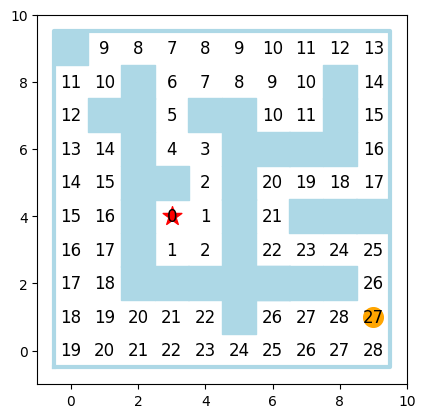

In [14]:
update(dist,maze,goal)
print_maze(maze, dist=dist, start=start, goal=goal)

Um nun den kürzesten Weg zum Ziel zu finden, können wir wieder rekursiv vorgehen:
- Wir starten beim Startpunkt
- Wir prüfen alle Nachbarpunkte (oben, unten, links, rechts)
- Sobald wir einen Punkt erreichen, der näher am Ziel ist als zuvor, gehen wir zu diesem Punkt und wiederholen den Vorgang.

In [7]:
def find_shortest_path(dist,path):
    x,y = path[-1]
    if dist[x][y] != 0:
        for (xp,yp) in [(x-1,y),(x,y-1),(x+1,y),(x,y+1)]:
            if 0 <= xp < n and 0 <= yp < n and dist[xp][yp] < dist[x][y]:
                path.append((xp,yp))
                return find_shortest_path(dist,path)
    return path

Wir testen nun alle Funktionen zusammen, um den kürzesten Weg in einem Labyrinth zu finden und zu visualisieren.

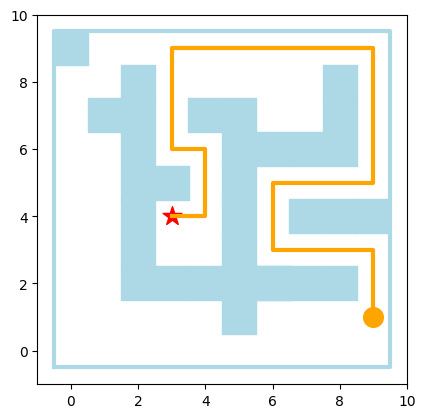

In [9]:
goal = (3,4)
start = (9,1)
path = [start]
dist = [[float('inf')]*n for _ in range(n)]
dist[goal[0]][goal[1]] = 0
update(dist,maze,goal)
path = find_shortest_path(dist,path)
print_maze(maze, path,start,goal)